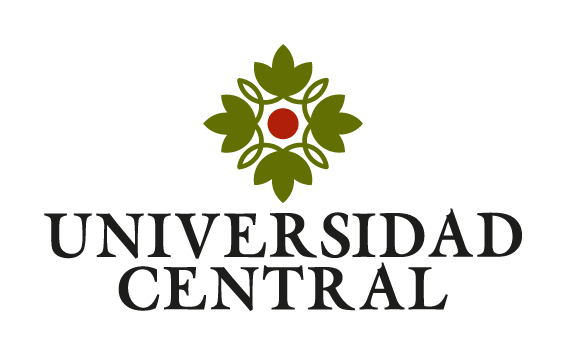

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 16 de 2026

Taller: Trabajo Final

# Etapa 3: Motor de Recuperación (Retrieval) y Búsqueda


Construcción del **cerebro semántico** del prototipo según el diagrama de arquitectura.


## Componentes
- **ChromaDB** → base de datos vectorial persistente (almacena embeddings + metadata)
- **LangChain-compatible** → orquestador (interfaz uniforme para retrieval, embeddings, filtros)
- **Longformer** (mismo de la Etapa 2) → encoder de consultas en el mismo espacio vectorial
- **Métrica:** similitud coseno (estándar para Longformer en RAG jurídico)
- **Estrategia:** retrieval híbrido — semántico (top-k coseno) + filtros por metadata (tipo_chunk, numeral, fecha, documento)

## Entrada (Etapa 2)
- `corpus_chunks_consolidado.json`
- `corpus_embeddings_consolidado.npy`

##  Salidas en `Retrieval/`

| Archivo / carpeta | Contenido |
|---|---|
| `chroma_db/` | ChromaDB persistente — colección `autos_anla_longformer` |
| `retriever_utils.py` | Clase `Retriever` reutilizable para Etapa 4 |

# HOJA DE RUTA A SEGUIR

0. Montar Google Drive
1. Instalar Dependencias (con pin de NumPy)
2. Instalar Librerías
3. Configuración de Rutas
4. Carga del Corpus Consolidado en Etapa 2
5. Carga del Longformer (encoder de consultas)
6. Preparación de Metadata para ChromaDB
7. Construcción de ChromaDB con Similitud de Coseno
8. Función de Retrieval Híbrido
8.1 Parent-Document Retrieval
9. Smoke Test: 4 Consultas Representativas
10. Exportar Utilidades Reutilizables para Etapa 4
11. Resumen Final


# 0\. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1\. Instalar Dependencias (con pin de NumPy)

**Importante:** después de ejecutar esta celda, **se debe reiniciar el runtime** (Entorno de ejecución → Reiniciar sesión) y luego ejecuta TODO desde la celda 2 en adelante. Esto evita el error `numpy.dtype size changed, may indicate binary incompatibility`.

In [ ]:
!pip install -q "numpy<2.0" "pandas>=2.0,<2.3" \
    chromadb==0.5.5 langchain==0.3.0 langchain-community==0.3.0 \
    transformers==4.44.2 sentencepiece tqdm

print('\n' + '=' * 60)
print('⚠ REINICIAR EL RUNTIME y ejecuta desde la celda siguiente')
print('  Menú: Entorno de ejecución → Reiniciar sesión')
print('=' * 60)


⚠ AHORA REINICIA EL RUNTIME y ejecuta desde la celda siguiente
  Menú: Entorno de ejecución → Reiniciar sesión


# 2\. Instalar Librerías

(Ejecutar después de reiniciar el runtime)

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from typing import List, Dict, Optional

import chromadb
from chromadb.config import Settings
from transformers import LongformerTokenizerFast, LongformerModel

# Verificar versiones (debug)
print(f'NumPy:   {np.__version__}')
print(f'Pandas:  {pd.__version__}')
print(f'Torch:   {torch.__version__}')
print(f'Chroma:  {chromadb.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NumPy:   1.26.4
Pandas:  2.2.2
Torch:   2.10.0+cu128
Chroma:  0.5.5


#3\. Configuración de Rutas

In [ ]:
BASE_DIR     = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final'
INPUT_DIR    = os.path.join(BASE_DIR, 'Segmentación')
OUTPUT_DIR   = os.path.join(BASE_DIR, 'Retrieval')
CHROMA_DIR   = os.path.join(OUTPUT_DIR, 'chroma_db')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHROMA_DIR, exist_ok=True)

print(f'Entrada (Etapa 2):  {INPUT_DIR}')
print(f'Salida (ChromaDB):  {CHROMA_DIR}')

Entrada (Etapa 2):  /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación
Salida (ChromaDB):  /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/chroma_db


# 4\. Carga del Corpus Consolidado en Etapa 2

In [ ]:
ruta_chunks = os.path.join(INPUT_DIR, 'corpus_chunks_consolidado.json')
ruta_emb    = os.path.join(INPUT_DIR, 'corpus_embeddings_consolidado.npy')

with open(ruta_chunks, 'r', encoding='utf-8') as f:
    corpus = json.load(f)

embeddings_matrix = np.load(ruta_emb)
chunks = corpus['chunks']

print(f'Documentos:       {corpus["total_documentos"]}')
print(f'Total chunks:     {corpus["total_chunks"]}')
print(f'Chunks texto:     {corpus["chunks_texto"]}')
print(f'Chunks tabla:     {corpus["chunks_tabla"]}')
print(f'Dim. embedding:   {corpus["dim_embedding"]}')
print(f'Embeddings shape: {embeddings_matrix.shape}')

assert len(chunks) == embeddings_matrix.shape[0], \
    f'Desalineación: {len(chunks)} chunks vs {embeddings_matrix.shape[0]} embeddings'
print('\n✓ Alineación chunks ↔ embeddings correcta')

Documentos:       5
Total chunks:     139
Chunks texto:     83
Chunks tabla:     56
Dim. embedding:   768
Embeddings shape: (139, 768)

✓ Alineación chunks ↔ embeddings correcta


# 5\. Carga del Longformer (encoder de consultas)

**Las consultas deben encodearse con el mismo modelo que generó los embeddings de los chunks**.

In [ ]:
MODEL_NAME    = 'allenai/longformer-base-4096'
MAX_MODEL_LEN = 4096

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

print('Cargando Longformer...')
tokenizer = LongformerTokenizerFast.from_pretrained(MODEL_NAME)
model     = LongformerModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
print('OK')

Dispositivo: cuda
Cargando Longformer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

OK


In [ ]:
def encodear_consulta(query: str) -> np.ndarray:
    """Encodea una consulta con Longformer (mean pooling) — mismo método que en Etapa 2."""
    token_ids = tokenizer.encode(query, add_special_tokens=False)
    ids = [tokenizer.cls_token_id] + token_ids + [tokenizer.sep_token_id]
    if len(ids) > MAX_MODEL_LEN:
        ids = ids[:MAX_MODEL_LEN]

    input_ids = torch.tensor([ids], device=device)
    attention_mask = torch.ones_like(input_ids)
    global_attention_mask = torch.zeros_like(input_ids)
    global_attention_mask[:, 0] = 1

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            global_attention_mask=global_attention_mask,
        )
    last_hidden = outputs.last_hidden_state
    mask = attention_mask.unsqueeze(-1).float()
    summed = (last_hidden * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return (summed / counts).squeeze(0).cpu().numpy().astype(np.float32)

# Test
test_emb = encodear_consulta('incumplimiento del plan de restauración ambiental')
print(f'Embedding de consulta shape: {test_emb.shape}')
print(f'Norma L2: {np.linalg.norm(test_emb):.4f}')

Input ids are automatically padded to be a multiple of `config.attention_window`: 512


Embedding de consulta shape: (768,)
Norma L2: 11.6137


# 6\. Preparación de Metadata para ChromaDB

ChromaDB exige metadata en tipos primitivos. Se incluyo `fecha_ordinal` (int `YYYYMMDD`) para poder usar operadores de rango `$gte`/`$lte`, que Chroma solo acepta sobre `int`/`float`.

In [ ]:
def fecha_a_ordinal(fecha_str: str) -> int:
    """Convierte 'YYYY-MM-DD' a int YYYYMMDD para filtros de rango en ChromaDB."""
    if not fecha_str:
        return 0
    try:
        return int(fecha_str.replace('-', ''))
    except (ValueError, AttributeError):
        return 0

# Test
print(fecha_a_ordinal('2023-01-01'))  # 20230101
print(fecha_a_ordinal('2024-04-18'))  # 20240418
print(fecha_a_ordinal(''))            # 0

20230101
20240418
0


In [ ]:
def preparar_metadata(chunk: dict) -> dict:
    """Convierte el chunk en metadata compatible con ChromaDB."""
    fecha_str = chunk.get('fecha_documento') or ''
    md = {
        'tipo_chunk':       chunk.get('tipo_chunk') or 'texto',
        'id_documento':     chunk.get('id_documento') or '',
        'filename':         chunk.get('filename') or '',
        'tipo_documento':   chunk.get('tipo_documento') or '',
        'numero_documento': str(chunk.get('numero_documento') or ''),
        'fecha_documento':  fecha_str,                          # str para mostrar
        'fecha_ordinal':    fecha_a_ordinal(fecha_str),         # int para filtrar rangos
        'bloque_id':        chunk.get('bloque_id') or '',
        'bloque_id_padre':  chunk.get('bloque_id_padre') or '',
        'numeral':          str(chunk.get('numeral') or ''),
        'tipo_numeral':     chunk.get('tipo_numeral') or '',
        'nivel':            int(chunk.get('nivel') or 0),
        'titulo_bloque':    (chunk.get('titulo_bloque') or '')[:500],
        'pagina_inicio':    int(chunk.get('pagina_inicio') or 0),
        'pagina_fin':       int(chunk.get('pagina_fin') or 0),
        'tabla_id':         chunk.get('tabla_id') or '',
        'tabla_fuente':     chunk.get('tabla_fuente') or '',
        'chunk_index':      int(chunk.get('chunk_index') or 0),
        'total_chunks_bloque': int(chunk.get('total_chunks_bloque') or 1),
        'n_tokens':         int(chunk.get('n_tokens') or 0),
    }
    dims = chunk.get('tabla_dimensiones')
    if isinstance(dims, dict):
        md['tabla_filas']    = int(dims.get('filas') or 0)
        md['tabla_columnas'] = int(dims.get('columnas') or 0)
    else:
        md['tabla_filas']    = 0
        md['tabla_columnas'] = 0
    return md

# Test rápido
print(json.dumps(preparar_metadata(chunks[0]), indent=2, ensure_ascii=False))

{
  "tipo_chunk": "texto",
  "id_documento": "4caa3a79-ffd2-44e2-bbcb-7918f4798f6f",
  "filename": "2554_1092_2023-02-28.pdf",
  "tipo_documento": "AUTO",
  "numero_documento": "1092",
  "fecha_documento": "2023-02-28",
  "fecha_ordinal": 20230228,
  "bloque_id": "3d5d1a7e-e2f3-47c8-8e99-37fad3a03124",
  "bloque_id_padre": "",
  "numeral": "INTRO",
  "tipo_numeral": "intro",
  "nivel": 0,
  "titulo_bloque": "ENCABEZADO Y PROEMIO",
  "pagina_inicio": 1,
  "pagina_fin": 1,
  "tabla_id": "",
  "tabla_fuente": "",
  "chunk_index": 0,
  "total_chunks_bloque": 1,
  "n_tokens": 276,
  "tabla_filas": 0,
  "tabla_columnas": 0
}


# 7\. Construcción de ChromaDB con Similitud de Coseno
Se emplea `PersistentClient` para que la colección quede guardada en Drive. La métrica coseno se configura con `hnsw:space=cosine` en la colección.

In [ ]:
COLLECTION_NAME = 'autos_anla_longformer'

client = chromadb.PersistentClient(
    path=CHROMA_DIR,
    settings=Settings(anonymized_telemetry=False),
)


try:
    client.delete_collection(COLLECTION_NAME)
    print(f'Colección previa eliminada: {COLLECTION_NAME}')
except Exception:
    print(f'No había colección previa: {COLLECTION_NAME}')

collection = client.create_collection(
    name=COLLECTION_NAME,
    metadata={'hnsw:space': 'cosine'},
)
print(f'✓ Colección creada con métrica COSINE: {COLLECTION_NAME}')

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Colección previa eliminada: autos_anla_longformer
✓ Colección creada con métrica COSINE: autos_anla_longformer


In [ ]:
BATCH_SIZE = 256

ids_all        = [c['chunk_id'] for c in chunks]
documents_all  = [c['texto'] for c in chunks]
metadatas_all  = [preparar_metadata(c) for c in chunks]
embeddings_all = embeddings_matrix.tolist()

n = len(ids_all)
print(f'Indexando {n} chunks en batches de {BATCH_SIZE}...')

for i in tqdm(range(0, n, BATCH_SIZE), desc='Indexando'):
    j = min(i + BATCH_SIZE, n)
    collection.add(
        ids=ids_all[i:j],
        documents=documents_all[i:j],
        metadatas=metadatas_all[i:j],
        embeddings=embeddings_all[i:j],
    )

print(f'\n✓ Indexación completa')
print(f'Documentos en colección: {collection.count()}')

Indexando 139 chunks en batches de 256...


Indexando:   0%|          | 0/1 [00:00<?, ?it/s]

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given



✓ Indexación completa
Documentos en colección: 139


#8\. Función de Retrieval Híbrido

Semántico (top-k coseno) + filtros opcionales por metadata. Los rangos de fecha usan `fecha_ordinal` (int).

In [ ]:
def buscar(
    query: str,
    top_k: int = 5,
    tipo_chunk: Optional[str] = None,
    filename: Optional[str] = None,
    numeral: Optional[str] = None,
    fecha_desde: Optional[str] = None,   # 'YYYY-MM-DD'
    fecha_hasta: Optional[str] = None,
    filtros_extra: Optional[dict] = None,
) -> List[Dict]:
    """
    Retrieval híbrido: semántico (coseno) + filtros por metadata.
    Devuelve lista de dicts con texto, metadata, distancia y similitud.
    """
    conds = []
    if tipo_chunk:
        conds.append({'tipo_chunk': {'$eq': tipo_chunk}})
    if filename:
        conds.append({'filename': {'$eq': filename}})
    if numeral:
        conds.append({'numeral': {'$eq': str(numeral)}})
    if fecha_desde:
        conds.append({'fecha_ordinal': {'$gte': fecha_a_ordinal(fecha_desde)}})
    if fecha_hasta:
        conds.append({'fecha_ordinal': {'$lte': fecha_a_ordinal(fecha_hasta)}})
    if filtros_extra:
        if isinstance(filtros_extra, list):
            conds.extend(filtros_extra)
        else:
            conds.append(filtros_extra)

    if not conds:
        where = None
    elif len(conds) == 1:
        where = conds[0]
    else:
        where = {'$and': conds}

    query_emb = encodear_consulta(query).tolist()

    results = collection.query(
        query_embeddings=[query_emb],
        n_results=top_k,
        where=where,
    )

    out = []
    for i in range(len(results['ids'][0])):
        dist = results['distances'][0][i]
        out.append({
            'chunk_id':  results['ids'][0][i],
            'texto':     results['documents'][0][i],
            'metadata':  results['metadatas'][0][i],
            'distancia': dist,
            'similitud': 1 - dist,
        })
    return out

print('Función buscar() definida.')

Función buscar() definida.


## 8.1 Parent-Document Retrieval

In [ ]:
def traer_bloque_padre(chunk_resultado: dict) -> Optional[Dict]:
    """Si el chunk es una tabla, recupera el texto del bloque padre desde ChromaDB."""
    md = chunk_resultado['metadata']
    if md.get('tipo_chunk') != 'tabla':
        return None
    bloque_padre_id = md.get('bloque_id_padre')
    if not bloque_padre_id:
        return None
    res = collection.get(
        where={'$and': [
            {'bloque_id':  {'$eq': bloque_padre_id}},
            {'tipo_chunk': {'$eq': 'texto'}},
        ]},
        limit=10,
    )
    if not res['ids']:
        return None
    items = list(zip(res['metadatas'], res['documents']))
    items.sort(key=lambda x: x[0].get('chunk_index', 0))
    return {
        'bloque_id': bloque_padre_id,
        'numeral':   items[0][0].get('numeral'),
        'titulo':    items[0][0].get('titulo_bloque'),
        'texto_completo': ' '.join(t for _, t in items),
    }

print('Función traer_bloque_padre() definida.')

Función traer_bloque_padre() definida.


#9\. Smoke Test: 4 Consultas Representativas

In [ ]:
def mostrar_resultados(resultados, query):
    print(f'\n{"═" * 75}')
    print(f'CONSULTA: {query}')
    print('═' * 75)
    for i, r in enumerate(resultados, 1):
        md = r['metadata']
        print(f'\n[{i}] similitud={r["similitud"]:.4f}  |  tipo={md["tipo_chunk"]}  |  '
              f'doc={md["filename"]}  |  numeral={md["numeral"]}  |  pág={md["pagina_inicio"]}-{md["pagina_fin"]}')
        print(f'    {r["texto"][:250]}...')

In [ ]:
# Consulta 1: búsqueda semántica pura
q1 = 'incumplimiento del plan de restauración y entrega del predio'
r1 = buscar(q1, top_k=5)
mostrar_resultados(r1, q1)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



═══════════════════════════════════════════════════════════════════════════
CONSULTA: incumplimiento del plan de restauración y entrega del predio
═══════════════════════════════════════════════════════════════════════════

[1] similitud=0.9838  |  tipo=texto  |  doc=2554_1092_2023-02-28.pdf  |  numeral=2  |  pág=6-6
    Plan de Desmantelamiento, Abandono y Restauración Final. (…)...

[2] similitud=0.9801  |  tipo=tabla  |  doc=2799_3668_2024-05-27.pdf  |  numeral=2  |  pág=12-12
    Concesión de aguas subterráneas.. Concepto Técnico No. 9174 del 26 de diciembre de 2023 :-------------------------------------------------------- Ley del 2019, anexando el...

[3] similitud=0.9801  |  tipo=tabla  |  doc=2799_3668_2024-05-27.pdf  |  numeral=2  |  pág=7-16
    Concesión de aguas subterráneas.. Concepto Técnico No. 9174 del 26 de diciembre de 2023 :-------------------------------------------------------- Ley del 2019, anexando el...

[4] similitud=0.9792  |  tipo=tabla  |  doc=2844_1451_2024

In [ ]:
# Consulta 2: solo tablas
q2 = 'requerimientos del concepto técnico que se mantienen o se modifican'
r2 = buscar(q2, top_k=5, tipo_chunk='tabla')
mostrar_resultados(r2, q2)


═══════════════════════════════════════════════════════════════════════════
CONSULTA: requerimientos del concepto técnico que se mantienen o se modifican
═══════════════════════════════════════════════════════════════════════════

[1] similitud=0.9801  |  tipo=tabla  |  doc=2799_3668_2024-05-27.pdf  |  numeral=2  |  pág=12-12
    Concesión de aguas subterráneas.. Concepto Técnico No. 9174 del 26 de diciembre de 2023 :-------------------------------------------------------- Ley del 2019, anexando el...

[2] similitud=0.9801  |  tipo=tabla  |  doc=2799_3668_2024-05-27.pdf  |  numeral=2  |  pág=7-16
    Concesión de aguas subterráneas.. Concepto Técnico No. 9174 del 26 de diciembre de 2023 :-------------------------------------------------------- Ley del 2019, anexando el...

[3] similitud=0.9799  |  tipo=tabla  |  doc=2844_1451_2024-03-18.pdf  |  numeral=4  |  pág=5-6
    Para la fase de operación y mantenimiento de los Oleoductos Vasconia — CIB y Vasconia — Velásquez los siguientes pro

In [ ]:
# Consulta 3: solo texto, fechas desde 2023
q3 = 'competencia de la ANLA para iniciar procedimiento sancionatorio ambiental'
r3 = buscar(q3, top_k=5, tipo_chunk='texto', fecha_desde='2023-01-01')
mostrar_resultados(r3, q3)


═══════════════════════════════════════════════════════════════════════════
CONSULTA: competencia de la ANLA para iniciar procedimiento sancionatorio ambiental
═══════════════════════════════════════════════════════════════════════════

[1] similitud=0.9829  |  tipo=texto  |  doc=2844_1451_2024-03-18.pdf  |  numeral=SEC_II  |  pág=3-3
    Antecedentes relevantes y actuación administrativa. Antecedentes permisivos — Expedientes LAM1801 y LAM6550-00...

[2] similitud=0.9793  |  tipo=texto  |  doc=2554_1092_2023-02-28.pdf  |  numeral=2  |  pág=6-6
    Plan de Desmantelamiento, Abandono y Restauración Final. (…)...

[3] similitud=0.9792  |  tipo=texto  |  doc=2844_1451_2024-03-18.pdf  |  numeral=3  |  pág=6-6
    Actos Administrativos.. La empresa CENIT TRANSPORTE Y LOGÍSTICA DE HIDROCARBUROS S.A.S., será responsable de:...

[4] similitud=0.9792  |  tipo=texto  |  doc=2799_3668_2024-05-27.pdf  |  numeral=SEC_IV  |  pág=16-16
    INCUMPLIMIENTO A LOS ACTOS ADMINISTRATIVOS. De acuerdo con l

In [ ]:
# Consulta 4: parent-document retrieval (tabla → bloque padre)
q4 = 'soportes documentales de entrega a paz y salvo del predio'
r4 = buscar(q4, top_k=3, tipo_chunk='tabla')
mostrar_resultados(r4, q4)

if r4:
    print('\n--- BLOQUE PADRE del resultado #1 (parent-document) ---')
    padre = traer_bloque_padre(r4[0])
    if padre:
        print(f'Bloque padre: numeral={padre["numeral"]}  |  título={(padre["titulo"] or "")[:100]}')
        print(f'Texto: {padre["texto_completo"][:400]}...')
    else:
        print('(esta tabla no tiene bloque padre — probablemente es tabla global)')


═══════════════════════════════════════════════════════════════════════════
CONSULTA: soportes documentales de entrega a paz y salvo del predio
═══════════════════════════════════════════════════════════════════════════

[1] similitud=0.9847  |  tipo=tabla  |  doc=2799_3668_2024-05-27.pdf  |  numeral=2  |  pág=12-12
    Concesión de aguas subterráneas.. Concepto Técnico No. 9174 del 26 de diciembre de 2023 :-------------------------------------------------------- Ley del 2019, anexando el...

[2] similitud=0.9847  |  tipo=tabla  |  doc=2799_3668_2024-05-27.pdf  |  numeral=2  |  pág=7-16
    Concesión de aguas subterráneas.. Concepto Técnico No. 9174 del 26 de diciembre de 2023 :-------------------------------------------------------- Ley del 2019, anexando el...

[3] similitud=0.9820  |  tipo=tabla  |  doc=2799_3668_2024-05-27.pdf  |  numeral=2  |  pág=7-16
    Concesión de aguas subterráneas.. Año de inicio de actividades autorizadas en la Licencia Ambiental :------------------------

#10\. Exportar Utilidades Reutilizables para Etapa 4

Clase `Retriever` autocontenida. Incluye los mismos arreglos (`fecha_ordinal`).

In [ ]:
retriever_code = '''"""
retriever_utils.py — utilidades para usar el motor de retrieval ANLA en otros notebooks.
Generado por Etapa 3 (v2: con fecha_ordinal para filtros de rango).

Uso típico:
    from retriever_utils import Retriever
    r = Retriever(chroma_dir="/content/drive/.../Retrieval/chroma_db")
    resultados = r.buscar("incumplimiento plan de restauración", top_k=5)
"""
import os
from typing import List, Dict, Optional

import numpy as np
import torch
import chromadb
from chromadb.config import Settings
from transformers import LongformerTokenizerFast, LongformerModel


def _fecha_a_ordinal(fecha_str: str) -> int:
    if not fecha_str:
        return 0
    try:
        return int(fecha_str.replace("-", ""))
    except (ValueError, AttributeError):
        return 0


class Retriever:
    def __init__(
        self,
        chroma_dir: str,
        collection_name: str = "autos_anla_longformer",
        model_name: str = "allenai/longformer-base-4096",
        max_model_len: int = 4096,
    ):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.max_model_len = max_model_len
        self.tokenizer = LongformerTokenizerFast.from_pretrained(model_name)
        self.model = LongformerModel.from_pretrained(model_name).to(self.device)
        self.model.eval()

        self.client = chromadb.PersistentClient(
            path=chroma_dir, settings=Settings(anonymized_telemetry=False)
        )
        self.collection = self.client.get_collection(collection_name)

    def encodear_consulta(self, query: str) -> np.ndarray:
        token_ids = self.tokenizer.encode(query, add_special_tokens=False)
        ids = [self.tokenizer.cls_token_id] + token_ids + [self.tokenizer.sep_token_id]
        if len(ids) > self.max_model_len:
            ids = ids[: self.max_model_len]
        input_ids = torch.tensor([ids], device=self.device)
        attention_mask = torch.ones_like(input_ids)
        global_attention_mask = torch.zeros_like(input_ids)
        global_attention_mask[:, 0] = 1
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                global_attention_mask=global_attention_mask,
            )
        last_hidden = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        summed = (last_hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return (summed / counts).squeeze(0).cpu().numpy().astype(np.float32)

    def buscar(
        self,
        query: str,
        top_k: int = 5,
        tipo_chunk: Optional[str] = None,
        filename: Optional[str] = None,
        numeral: Optional[str] = None,
        fecha_desde: Optional[str] = None,
        fecha_hasta: Optional[str] = None,
        filtros_extra: Optional[dict] = None,
    ) -> List[Dict]:
        conds = []
        if tipo_chunk:
            conds.append({"tipo_chunk": {"$eq": tipo_chunk}})
        if filename:
            conds.append({"filename": {"$eq": filename}})
        if numeral:
            conds.append({"numeral": {"$eq": str(numeral)}})
        if fecha_desde:
            conds.append({"fecha_ordinal": {"$gte": _fecha_a_ordinal(fecha_desde)}})
        if fecha_hasta:
            conds.append({"fecha_ordinal": {"$lte": _fecha_a_ordinal(fecha_hasta)}})
        if filtros_extra:
            if isinstance(filtros_extra, list):
                conds.extend(filtros_extra)
            else:
                conds.append(filtros_extra)
        if not conds:
            where = None
        elif len(conds) == 1:
            where = conds[0]
        else:
            where = {"$and": conds}

        query_emb = self.encodear_consulta(query).tolist()
        results = self.collection.query(
            query_embeddings=[query_emb], n_results=top_k, where=where
        )
        out = []
        for i in range(len(results["ids"][0])):
            dist = results["distances"][0][i]
            out.append({
                "chunk_id":  results["ids"][0][i],
                "texto":     results["documents"][0][i],
                "metadata":  results["metadatas"][0][i],
                "distancia": dist,
                "similitud": 1 - dist,
            })
        return out

    def traer_bloque_padre(self, chunk_resultado: dict) -> Optional[Dict]:
        md = chunk_resultado["metadata"]
        if md.get("tipo_chunk") != "tabla":
            return None
        bloque_padre_id = md.get("bloque_id_padre")
        if not bloque_padre_id:
            return None
        res = self.collection.get(
            where={"$and": [
                {"bloque_id":  {"$eq": bloque_padre_id}},
                {"tipo_chunk": {"$eq": "texto"}},
            ]},
            limit=10,
        )
        if not res["ids"]:
            return None
        items = list(zip(res["metadatas"], res["documents"]))
        items.sort(key=lambda x: x[0].get("chunk_index", 0))
        return {
            "bloque_id": bloque_padre_id,
            "numeral":   items[0][0].get("numeral"),
            "titulo":    items[0][0].get("titulo_bloque"),
            "texto_completo": " ".join(t for _, t in items),
        }
'''

ruta_utils = os.path.join(OUTPUT_DIR, 'retriever_utils.py')
with open(ruta_utils, 'w', encoding='utf-8') as f:
    f.write(retriever_code)
print(f'✓ Utilidades exportadas: {ruta_utils}')

✓ Utilidades exportadas: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/retriever_utils.py


# 11\. Resumen Final

In [ ]:
print('=' * 65)
print('MOTOR DE RETRIEVAL — ETAPA 3 (LISTO)')
print('=' * 65)
print(f'Base vectorial:      ChromaDB persistente')
print(f'Ubicación:           {CHROMA_DIR}')
print(f'Colección:           {COLLECTION_NAME}')
print(f'Chunks indexados:    {collection.count()}')
print(f'Métrica:             cosine similarity')
print(f'Encoder de consulta: {MODEL_NAME}')
print(f'Dim. embeddings:     768')
print()
print('Capacidades:')
print('  ✓ Búsqueda semántica top-k')
print('  ✓ Filtros por: tipo_chunk, filename, numeral, fecha (rangos)')
print('  ✓ Parent-document retrieval (tabla → bloque padre)')
print('  ✓ Utilidades exportadas → retriever_utils.py')

MOTOR DE RETRIEVAL — ETAPA 3 (LISTO)
Base vectorial:      ChromaDB persistente
Ubicación:           /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/chroma_db
Colección:           autos_anla_longformer
Chunks indexados:    139
Métrica:             cosine similarity
Encoder de consulta: allenai/longformer-base-4096
Dim. embeddings:     768

Capacidades:
  ✓ Búsqueda semántica top-k
  ✓ Filtros por: tipo_chunk, filename, numeral, fecha (rangos)
  ✓ Parent-document retrieval (tabla → bloque padre)
  ✓ Utilidades exportadas → retriever_utils.py
